# Understanding the Scatter Plot

A scatter plot places each observation as a dot at coordinates (X, Y). It is the primary tool for visualising the **relationship** between two numerical variables — direction, strength, linearity, and anomalies all become visible at once.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

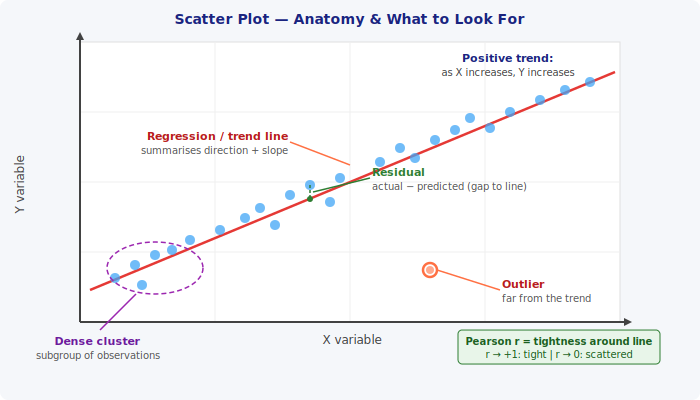

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="400"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="700" height="400" fill="#F5F7FA" rx="8"/>
  <text x="350" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Scatter Plot — Anatomy &amp; What to Look For</text>

  <!-- plot area -->
  <rect x="80" y="42" width="540" height="280" fill="white" stroke="#E0E0E0"/>

  <!-- gridlines -->
  <line x1="80" y1="112" x2="620" y2="112" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="80" y1="182" x2="620" y2="182" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="80" y1="252" x2="620" y2="252" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="215" y1="42" x2="215" y2="322" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="350" y1="42" x2="350" y2="322" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="485" y1="42" x2="485" y2="322" stroke="#F0F0F0" stroke-width="1"/>

  <!-- regression line: positive slope through (80,290) to (620,70) -->
  <line x1="90" y1="290" x2="615" y2="72" stroke="#E53935" stroke-width="2.5"/>

  <!-- scattered data points (roughly along the line with noise) -->
  <!-- Cluster near bottom-left -->
  <circle cx="115" cy="278" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="135" cy="265" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="155" cy="255" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="142" cy="285" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="172" cy="250" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="190" cy="240" r="5" fill="#42A5F5" opacity="0.75"/>
  <!-- Mid cluster -->
  <circle cx="220" cy="230" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="245" cy="218" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="260" cy="208" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="275" cy="225" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="290" cy="195" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="310" cy="185" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="330" cy="202" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="340" cy="178" r="5" fill="#42A5F5" opacity="0.75"/>
  <!-- Upper-right cluster -->
  <circle cx="380" cy="162" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="400" cy="148" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="415" cy="158" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="435" cy="140" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="455" cy="130" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="470" cy="118" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="490" cy="128" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="510" cy="112" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="540" cy="100" r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="565" cy="90"  r="5" fill="#42A5F5" opacity="0.75"/>
  <circle cx="590" cy="82"  r="5" fill="#42A5F5" opacity="0.75"/>

  <!-- Outlier point -->
  <circle cx="430" cy="270" r="7" fill="none" stroke="#FF7043" stroke-width="2.5"/>
  <circle cx="430" cy="270" r="4" fill="#FF7043" opacity="0.6"/>

  <!-- Residual line from an example point to the regression line -->
  <!-- point (310,185), line y at x=310: intercept=290+(72-290)*(310-90)/(615-90) = 290-218*(220/525)=290-91=199 -->
  <line x1="310" y1="185" x2="310" y2="199" stroke="#2E7D32" stroke-width="1.5" stroke-dasharray="3,2"/>
  <circle cx="310" cy="199" r="3" fill="#2E7D32"/>

  <!-- axes -->
  <line x1="80" y1="322" x2="624" y2="322" stroke="#424242" stroke-width="2"/>
  <line x1="80" y1="322" x2="80"  y2="40"  stroke="#424242" stroke-width="2"/>
  <polygon points="624,318 632,322 624,326" fill="#424242"/>
  <polygon points="76,40 80,32 84,40"       fill="#424242"/>
  <text x="352" y="344" text-anchor="middle" font-size="12" fill="#424242">X variable</text>
  <text x="24" y="185" text-anchor="middle" font-size="12" fill="#424242"
        transform="rotate(-90 24 185)">Y variable</text>

  <!-- ── ANNOTATIONS ── -->

  <!-- Regression line label -->
  <line x1="350" y1="165" x2="290" y2="142" stroke="#FF7043" stroke-width="1.5"/>
  <text x="288" y="140" text-anchor="end" font-size="11" font-weight="bold" fill="#B71C1C">Regression / trend line</text>
  <text x="288" y="154" text-anchor="end" font-size="10" fill="#555">summarises direction + slope</text>

  <!-- Positive trend arrow -->
  <text x="508" y="62" text-anchor="middle" font-size="11" font-weight="bold" fill="#1A237E">Positive trend:</text>
  <text x="508" y="76" text-anchor="middle" font-size="10" fill="#424242">as X increases, Y increases</text>

  <!-- Residual annotation -->
  <line x1="313" y1="192" x2="370" y2="178" stroke="#2E7D32" stroke-width="1.5"/>
  <text x="372" y="176" font-size="11" font-weight="bold" fill="#2E7D32">Residual</text>
  <text x="372" y="190" font-size="10" fill="#555">actual − predicted (gap to line)</text>

  <!-- Outlier annotation -->
  <line x1="437" y1="270" x2="500" y2="290" stroke="#FF7043" stroke-width="1.5"/>
  <text x="502" y="288" font-size="11" font-weight="bold" fill="#B71C1C">Outlier</text>
  <text x="502" y="302" font-size="10" fill="#555">far from the trend</text>

  <!-- Cluster annotation -->
  <ellipse cx="155" cy="268" rx="48" ry="26" fill="none" stroke="#9C27B0" stroke-width="1.5" stroke-dasharray="5,3"/>
  <line x1="136" y1="294" x2="100" y2="330" stroke="#9C27B0" stroke-width="1.5"/>
  <text x="98" y="345" text-anchor="middle" font-size="11" font-weight="bold" fill="#6A1B9A">Dense cluster</text>
  <text x="98" y="359" text-anchor="middle" font-size="10" fill="#555">subgroup of observations</text>

  <!-- Correlation label -->
  <rect x="458" y="330" width="202" height="34" fill="#E8F5E9" rx="4" stroke="#2E7D32" stroke-width="1"/>
  <text x="559" y="345" text-anchor="middle" font-size="10" font-weight="bold" fill="#1B5E20">Pearson r = tightness around line</text>
  <text x="559" y="358" text-anchor="middle" font-size="10" fill="#1B5E20">r → +1: tight  |  r → 0: scattered</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Scatter Plot

| Feature | What it tells you |
|---|---|
| **Upward trend** | Positive correlation — X and Y increase together |
| **Downward trend** | Negative correlation — X increases, Y decreases |
| **No pattern / cloud** | No linear relationship (r ≈ 0) |
| **Tight around the line** | Strong relationship (|r| close to 1) |
| **Wide scatter** | Weak relationship |
| **Curved pattern** | Non-linear — Pearson r will understate it |
| **Fan shape** | Heteroscedastic — variance grows with X |
| **Isolated point far from cloud** | Outlier / leverage point |
| **Two separate clouds** | Two distinct subgroups |

**Always add a regression line** to make the trend explicit, and use a transparency (`alpha`) to reveal point density.

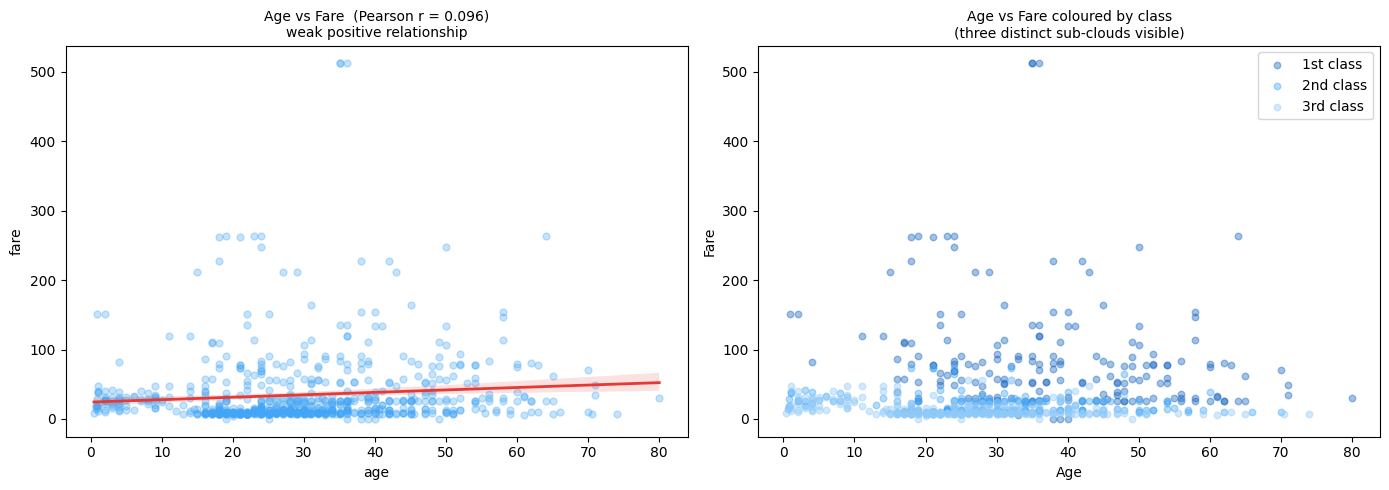

In [3]:
df = sns.load_dataset('titanic')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter + regression line
sns.regplot(x='age', y='fare', data=df, ax=axes[0],
            scatter_kws=dict(alpha=0.3, s=25, color='#42A5F5'),
            line_kws=dict(color='#E53935', linewidth=2))
r = df[['age','fare']].dropna().corr().iloc[0,1]
axes[0].set_title(f'Age vs Fare  (Pearson r = {r:.3f})\nweak positive relationship', fontsize=10)

# scatter coloured by class to reveal subgroups
for pclass, color, label in [(1,'#1565C0','1st class'),(2,'#42A5F5','2nd class'),(3,'#90CAF9','3rd class')]:
    sub = df[df['pclass']==pclass][['age','fare']].dropna()
    axes[1].scatter(sub['age'], sub['fare'], alpha=0.4, s=22, color=color, label=label)
axes[1].set_title('Age vs Fare coloured by class\n(three distinct sub-clouds visible)', fontsize=10)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Fare')
axes[1].legend()

plt.tight_layout()
plt.show()

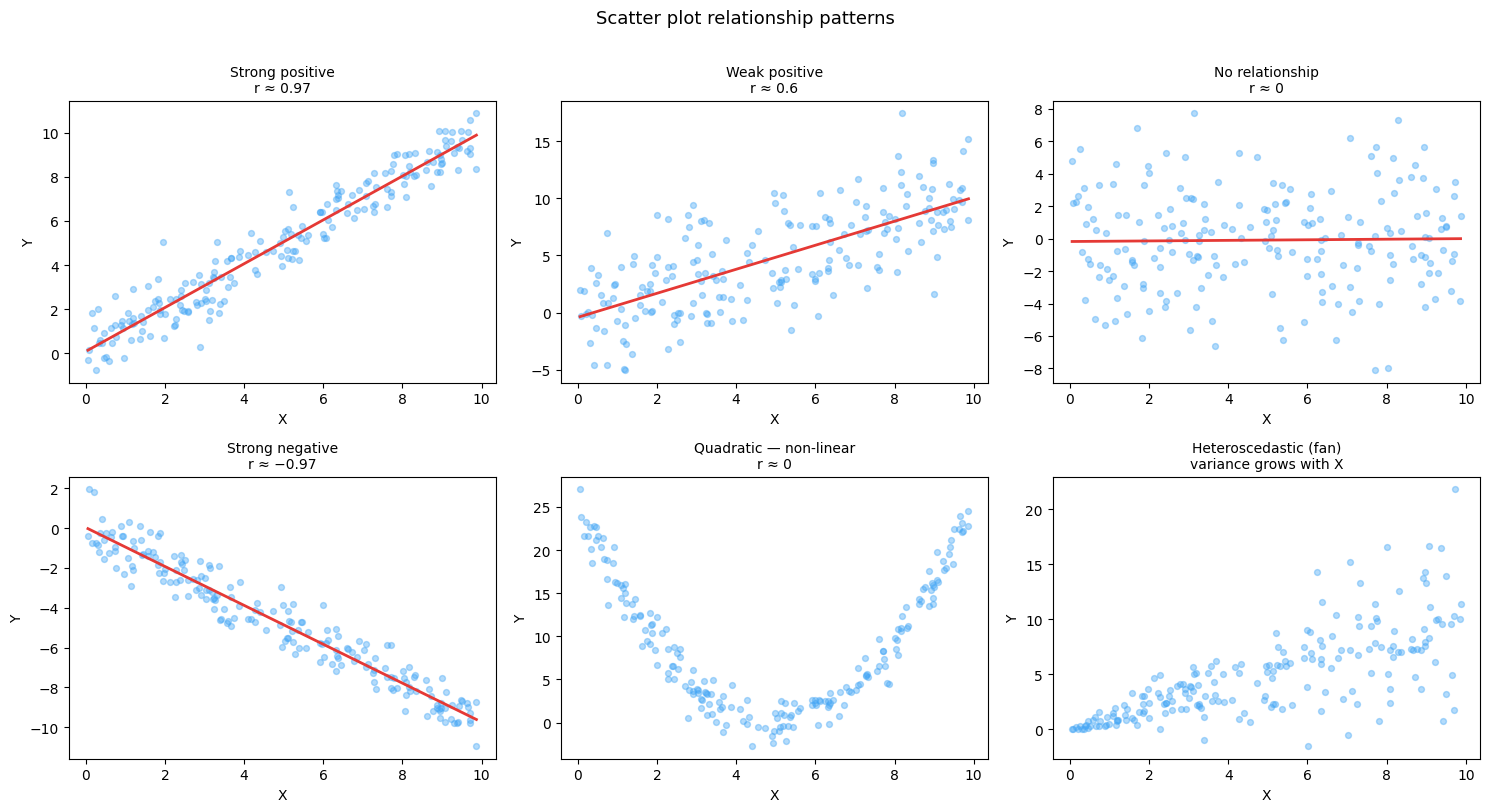

In [4]:
# Six relationship patterns — the scatter plot gallery
np.random.seed(42)
n = 200
x = np.random.uniform(0, 10, n)

patterns = [
    (x + np.random.randn(n)*0.8,         'Strong positive\nr ≈ 0.97'),
    (x + np.random.randn(n)*3,            'Weak positive\nr ≈ 0.6'),
    (np.random.randn(n)*3,                'No relationship\nr ≈ 0'),
    (-x + np.random.randn(n)*0.8,         'Strong negative\nr ≈ −0.97'),
    ((x-5)**2 + np.random.randn(n)*1.5,   'Quadratic — non-linear\nr ≈ 0'),
    (x + x*np.random.randn(n)*0.5,        'Heteroscedastic (fan)\nvariance grows with X'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (y, title) in zip(axes.flat, patterns):
    r = np.corrcoef(x, y)[0,1]
    ax.scatter(x, y, alpha=0.4, s=18, color='#42A5F5')
    if 'Quadratic' not in title and 'fan' not in title.lower():
        m = np.polyfit(x, y, 1)
        xr = np.array([x.min(), x.max()])
        ax.plot(xr, np.polyval(m, xr), color='#E53935', linewidth=2)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle('Scatter plot relationship patterns', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Relationship between two numerical variables |
| **Direction** | Upward / downward slope of the point cloud |
| **Strength** | Tightness around the regression line (Pearson r) |
| **Non-linearity** | Curved pattern → use Spearman or MI instead of Pearson |
| **Heteroscedasticity** | Fan shape → variance is not constant (violates regression assumptions) |
| **Colour by group** | Reveals subgroup structure invisible in a plain scatter |